In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import re, json, glob, math, random, pickle, hashlib, itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             f1_score, confusion_matrix, roc_curve, precision_recall_curve)
from scipy import stats

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORK = "/kaggle/working"
os.makedirs(WORK, exist_ok=True)

SEEDS = [42, 1, 7]
GLOBAL_SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 4
EPOCHS = 25
PATIENCE = 5

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
_MEAN_D = IMAGENET_MEAN.to(DEVICE)
_STD_D  = IMAGENET_STD.to(DEVICE)

def normalize_batch(x):
    return (x - _MEAN_D) / _STD_D

def set_determinism(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws); random.seed(ws)

set_determinism(GLOBAL_SEED)
print("Device:", DEVICE, "| torch", torch.__version__)
print("EPOCHS:", EPOCHS, "| PATIENCE:", PATIENCE, "| SEEDS:", SEEDS)

ARCHS = ["resnet18", "mobilenetv3"]
print("ARCHS:", ARCHS, flush=True)

Device: cuda | torch 2.10.0+cu128
EPOCHS: 25 | PATIENCE: 5 | SEEDS: [42, 1, 7]
ARCHS: ['resnet18', 'mobilenetv3']


In [2]:
import torch.torch_version
torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])
print("safe globals registered")

safe globals registered


In [3]:
import os, shutil, glob
WORK = "/kaggle/working"
os.makedirs(WORK, exist_ok=True)
src = sorted(glob.glob("/kaggle/input/**/resnet18__*.pt", recursive=True))
print("found in inputs:", len(src))
for p in src:
    dst = os.path.join(WORK, os.path.basename(p))
    if not os.path.exists(dst):
        shutil.copy2(p, dst)
print("in WORK:", len([f for f in os.listdir(WORK) if f.endswith(".pt")]), "checkpoints")

found in inputs: 15
in WORK: 15 checkpoints


In [4]:
PREFERRED = "/kaggle/input/datasets/ismailupal/cell-images-for-detecting-malaria/1.cell-images-for-detecting-malaria/cell_images"

def _valid(p):
    return (os.path.isdir(os.path.join(p, "Parasitized"))
            and os.path.isdir(os.path.join(p, "Uninfected")))

if _valid(PREFERRED):
    DATA_ROOT = PREFERRED
    print("Using preferred DATA_ROOT.")
else:
    cands = [c for c in sorted(glob.glob("/kaggle/input/**/cell_images", recursive=True)) if _valid(c)]
    assert cands, "cell_images/{Parasitized,Uninfected} not found under /kaggle/input"
    if len(cands) > 1:
        print("WARNING: multiple candidates, using the first:")
        for c in cands: print("   ", c)
    DATA_ROOT = cands[0]

print("DATA_ROOT:", DATA_ROOT)
n_para = len([f for f in os.listdir(os.path.join(DATA_ROOT, "Parasitized")) if f.lower().endswith(".png")])
n_unin = len([f for f in os.listdir(os.path.join(DATA_ROOT, "Uninfected"))  if f.lower().endswith(".png")])
print(f"Parasitized: {n_para} | Uninfected: {n_unin}   (expect 13779 / 13779)")
assert n_para == 13779 and n_unin == 13779, "Unexpected PNG counts"
assert n_para + n_unin == 27558

Using preferred DATA_ROOT.
DATA_ROOT: /kaggle/input/datasets/ismailupal/cell-images-for-detecting-malaria/1.cell-images-for-detecting-malaria/cell_images
Parasitized: 13779 | Uninfected: 13779   (expect 13779 / 13779)


In [5]:
def get_case_id(filename):
    m = re.search(r'^C(\d+)', filename)
    return int(m.group(1)) if m else None

def collect_samples(root):
    out = []
    for label, cls in enumerate(["Uninfected", "Parasitized"]):
        d = os.path.join(root, cls)
        for fn in sorted(os.listdir(d)):
            if fn.lower().endswith(".png"):
                out.append({"path": os.path.join(d, fn), "label": label,
                            "case": get_case_id(fn), "file": fn})
    return out

samples = collect_samples(DATA_ROOT)
assert sum(1 for s in samples if s["case"] is None) == 0, "unparseable case IDs"
cases = sorted({s["case"] for s in samples})
print(f"Total images: {len(samples)} | unique cases: {len(cases)}  (expect 27558 / 200)")

case_has_pos = {c: 0 for c in cases}
for s in samples:
    if s["label"] == 1:
        case_has_pos[s["case"]] = 1
strat = [case_has_pos[c] for c in cases]

train_c, temp_c = train_test_split(cases, test_size=0.30, random_state=GLOBAL_SEED, stratify=strat)
val_c, test_c = train_test_split(temp_c, test_size=0.50, random_state=GLOBAL_SEED,
                                 stratify=[case_has_pos[c] for c in temp_c])

def subset(cset):
    cset = set(cset)
    return [s for s in samples if s["case"] in cset]

train_samples, val_samples, test_samples = subset(train_c), subset(val_c), subset(test_c)

def split_hash(sset):
    h = hashlib.sha256()
    for f in sorted(s["file"] for s in sset):
        h.update(f.encode())
    return h.hexdigest()[:16]

SPLIT_HASHES = {n: split_hash(s) for n, s in
                [("train", train_samples), ("val", val_samples), ("test", test_samples)]}
for n, s in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    pos = sum(x["label"] for x in s)
    print(f"{n}: {len(s)} imgs / {len(set(x['case'] for x in s))} cases | "
          f"{pos} parasitized / {len(s)-pos} uninfected | hash {SPLIT_HASHES[n]}")

EXPECTED_HASHES = {"train": "3ed101445b5fa25e", "val": "6c27f767fc6f2e59", "test": "45a6677551543a92"}
assert SPLIT_HASHES == EXPECTED_HASHES, f"SPLIT CHANGED: {SPLIT_HASHES} vs {EXPECTED_HASHES}"
print("Split matches the recorded hashes.")

pd.DataFrame([{"split": n, "file": s["file"], "label": s["label"], "case": s["case"]}
              for n, ss in [("train", train_samples), ("val", val_samples), ("test", test_samples)]
              for s in ss]).to_csv(os.path.join(WORK, "split_manifest.csv"), index=False)
json.dump(SPLIT_HASHES, open(os.path.join(WORK, "split_hashes.json"), "w"))
print("Saved manifest and hashes.")

Total images: 27558 | unique cases: 200  (expect 27558 / 200)
train: 18555 imgs / 140 cases | 8974 parasitized / 9581 uninfected | hash 3ed101445b5fa25e
val: 4878 imgs / 30 cases | 2756 parasitized / 2122 uninfected | hash 6c27f767fc6f2e59
test: 4125 imgs / 30 cases | 2049 parasitized / 2076 uninfected | hash 45a6677551543a92
Split matches the recorded hashes.
Saved manifest and hashes.


In [6]:
class MalariaDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples, self.transform = samples, transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s["path"]).convert("RGB")
        return self.transform(img), s["label"]

class GreenOnly:
    def __call__(self, img):
        a = np.array(img)
        g = a[:, :, 1]
        return Image.fromarray(np.stack([g, g, g], axis=-1))

_BASE_GEOM = [T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(), T.RandomRotation(15)]

TRAIN_TF = {
    "baseline": T.Compose(_BASE_GEOM + [T.ToTensor()]),
    "colour_only": T.Compose(_BASE_GEOM + [
        T.RandomApply([T.Grayscale(num_output_channels=3)], p=0.25),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.5),
        T.ToTensor()]),
    "colour_plus_blur": T.Compose(_BASE_GEOM + [
        T.RandomApply([T.Grayscale(num_output_channels=3)], p=0.25),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.4, hue=0.5),
        T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
        T.ToTensor()]),
    "gray_trained": T.Compose(_BASE_GEOM + [
        T.Grayscale(num_output_channels=3), T.ToTensor()]),
    "green_trained": T.Compose(_BASE_GEOM + [
        T.Lambda(lambda im: GreenOnly()(im)), T.ToTensor()]),
}

EVAL_TF_PLAIN = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
EVAL_TF_GRAY  = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
                           T.Grayscale(num_output_channels=3), T.ToTensor()])
EVAL_TF_GREEN = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),
                           T.Lambda(lambda im: GreenOnly()(im)), T.ToTensor()])

VARIANT_EVAL_TF = {
    "baseline": EVAL_TF_PLAIN, "colour_only": EVAL_TF_PLAIN, "colour_plus_blur": EVAL_TF_PLAIN,
    "gray_trained": EVAL_TF_GRAY, "green_trained": EVAL_TF_GREEN,
}
PROBE_VARIANTS = ["baseline", "colour_only", "colour_plus_blur"]

def make_loader(samples, transform, shuffle=False, bs=BATCH_SIZE, seed=GLOBAL_SEED):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(MalariaDataset(samples, transform), batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
                      worker_init_fn=seed_worker, generator=g,
                      persistent_workers=(NUM_WORKERS > 0))

val_loader_plain = make_loader(val_samples, EVAL_TF_PLAIN)
val_loader_gray  = make_loader(val_samples, EVAL_TF_GRAY)
val_loader_green = make_loader(val_samples, EVAL_TF_GREEN)
VARIANT_VAL_LOADER = {"baseline": val_loader_plain, "colour_only": val_loader_plain,
                      "colour_plus_blur": val_loader_plain,
                      "gray_trained": val_loader_gray, "green_trained": val_loader_green}
print("Loaders ready.")

Loaders ready.


In [7]:
class Grayscale3Ch:
    def __call__(self, img): return TF.to_grayscale(img, num_output_channels=3)

class HueRotate:
    def __init__(self, degrees): self.factor = degrees / 360.0
    def __call__(self, img): return TF.adjust_hue(img, self.factor)

class ChannelPermute:
    def __init__(self, order): self.order = order
    def __call__(self, img): return Image.fromarray(np.array(img)[:, :, self.order])

class StrongColorJitter:
    def __init__(self):
        self.j = T.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.5, hue=0.15)
    def __call__(self, img): return self.j(img)

class GaussianBlurControl:
    def __init__(self, kernel_size=9, sigma=2.5):
        self.b = T.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
    def __call__(self, img): return self.b(img)

class GaussianNoiseControl:
    def __init__(self, std=0.08, seed=GLOBAL_SEED): self.std, self.seed = std, seed
    def __call__(self, t):
        g = torch.Generator(device=t.device); g.manual_seed(self.seed)
        n = torch.randn(t.shape, generator=g, device=t.device, dtype=t.dtype) * self.std
        return torch.clamp(t + n, 0.0, 1.0)

class ZeroChannel:
    def __init__(self, idx): self.idx = idx
    def __call__(self, img):
        a = np.array(img).copy(); a[:, :, self.idx] = 0
        return Image.fromarray(a)

class KeepOnlyChannel:
    def __init__(self, idx): self.idx = idx
    def __call__(self, img):
        a = np.array(img).copy()
        for i in range(3):
            if i != self.idx: a[:, :, i] = 0
        return Image.fromarray(a)

PIL_INTERVENTIONS = {
    "grayscale":           Grayscale3Ch(),
    "hue_30":              HueRotate(30),
    "hue_60":              HueRotate(60),
    "hue_90":              HueRotate(90),
    "channel_BGR":         ChannelPermute([2, 1, 0]),
    "channel_GBR":         ChannelPermute([1, 2, 0]),
    "channel_GRB":         ChannelPermute([1, 0, 2]),
    "color_jitter_strong": StrongColorJitter(),
    "blur_control":        GaussianBlurControl(),
}
TENSOR_INTERVENTIONS = {"noise_control": GaussianNoiseControl(std=0.08)}

ABLATIONS = {f"zero_{c}": ZeroChannel(i) for i, c in enumerate("RGB")}
ABLATIONS.update({f"only_{c}": KeepOnlyChannel(i) for i, c in enumerate("RGB")})

HEADLINE = ["clean", "grayscale", "hue_90", "channel_GRB", "channel_GBR",
            "channel_BGR", "blur_control", "noise_control"]
print("Interventions:", list(PIL_INTERVENTIONS) + list(TENSOR_INTERVENTIONS))
print("Ablations:", list(ABLATIONS))

Interventions: ['grayscale', 'hue_30', 'hue_60', 'hue_90', 'channel_BGR', 'channel_GBR', 'channel_GRB', 'color_jitter_strong', 'blur_control', 'noise_control']
Ablations: ['zero_R', 'zero_G', 'zero_B', 'only_R', 'only_G', 'only_B']


In [8]:
def ece_equal_width(labels, probs, preds, n_bins=15):
    conf = np.maximum(probs, 1 - probs)
    correct = (preds == labels).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece, stats_out = 0.0, []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() == 0:
            stats_out.append((lo, hi, np.nan, np.nan, 0)); continue
        a, c = correct[m].mean(), conf[m].mean()
        ece += (m.sum() / len(labels)) * abs(a - c)
        stats_out.append((lo, hi, a, c, int(m.sum())))
    return ece, stats_out

def ece_equal_mass(labels, probs, preds, n_bins=15):
    conf = np.maximum(probs, 1 - probs)
    correct = (preds == labels).astype(float)
    order = np.argsort(conf)
    ece = 0.0
    for chunk in np.array_split(order, n_bins):
        if len(chunk) == 0: continue
        ece += (len(chunk) / len(labels)) * abs(correct[chunk].mean() - conf[chunk].mean())
    return ece

def brier(labels, probs):
    return float(np.mean((probs - labels) ** 2))

def precision_at_sensitivity(labels, probs, target=0.90):
    prec, rec, _ = precision_recall_curve(labels, probs)
    ok = rec >= target
    return float(prec[ok].max()) if ok.any() else float("nan")

def metric_pack(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    out = {
        "threshold": threshold,
        "accuracy": float((preds == labels).mean()),
        "sensitivity": float(tp / (tp + fn)) if (tp + fn) else np.nan,
        "specificity": float(tn / (tn + fp)) if (tn + fp) else np.nan,
        "precision": float(precision_score(labels, preds, zero_division=0)),
        "f1": float(f1_score(labels, preds, zero_division=0)),
        "mean_confidence": float(np.mean(np.maximum(probs, 1 - probs))),
        "brier": brier(labels, probs),
    }
    out["ece"], _ = ece_equal_width(labels, probs, preds)
    out["ece_adaptive"] = ece_equal_mass(labels, probs, preds)
    try:
        out["auroc"] = float(roc_auc_score(labels, probs))
        out["auprc"] = float(average_precision_score(labels, probs))
        out["prec_at_sens90"] = precision_at_sensitivity(labels, probs, 0.90)
    except ValueError:
        out["auroc"] = out["auprc"] = out["prec_at_sens90"] = np.nan
    return out

def bootstrap_ci(labels, probs, fn, n_boot=1000, seed=GLOBAL_SEED, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(labels); vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try: vals.append(fn(labels[idx], probs[idx]))
        except Exception: pass
    if not vals: return (np.nan, np.nan)
    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)
print("Metrics ready.")

Metrics ready.


In [9]:
def build_resnet18():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m.to(DEVICE)

def build_mobilenetv3():
    m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, 2)
    return m.to(DEVICE)

BUILDERS = {"resnet18": build_resnet18, "mobilenetv3": build_mobilenetv3}

def ckpt_path(arch, variant, seed):
    return os.path.join(WORK, f"{arch}__{variant}__seed{seed}.pt")

def build_meta(arch, variant, seed, best_val_loss, epochs_run):
    return {"arch": arch, "variant": variant, "seed": seed,
            "split_hash_train": SPLIT_HASHES["train"],
            "split_hash_val": SPLIT_HASHES["val"],
            "split_hash_test": SPLIT_HASHES["test"],
            "normalization": "imagenet_mean_std",
            "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
            "epochs_max": EPOCHS, "epochs_run": epochs_run, "patience": PATIENCE,
            "best_val_loss": float(best_val_loss),
            "amp": True, "cudnn_deterministic": True,
            "torch": str(torch.__version__), "code_version": "v3"}

def check_meta(meta, arch, variant, seed):
    if meta is None:
        return ["no metadata (pre-v3 checkpoint)"]
    bad = []
    for k, want in [("arch", arch), ("variant", variant), ("seed", seed),
                    ("split_hash_train", SPLIT_HASHES["train"]),
                    ("split_hash_test", SPLIT_HASHES["test"]),
                    ("normalization", "imagenet_mean_std"),
                    ("img_size", IMG_SIZE), ("epochs_max", EPOCHS),
                    ("code_version", "v3")]:
        if meta.get(k) != want:
            bad.append(f"{k}: file={meta.get(k)!r} expected={want!r}")
    return bad

def run_epoch(model, loader, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    tot_loss = correct = total = 0
    crit = nn.CrossEntropyLoss()
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs = normalize_batch(imgs.to(DEVICE, non_blocking=True))
            labels = labels.to(DEVICE, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                    out = model(imgs); loss = crit(out, labels)
                scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            else:
                out = model(imgs); loss = crit(out, labels)
            tot_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return tot_loss / total, correct / total

def train_one(arch, variant, seed, epochs=None, patience=None, force=False):
    epochs = EPOCHS if epochs is None else epochs
    patience = PATIENCE if patience is None else patience
    path = ckpt_path(arch, variant, seed)
    if os.path.exists(path) and not force:
        try:
            blob = torch.load(path, map_location="cpu")
            bad = check_meta(blob.get("meta") if isinstance(blob, dict) else None,
                             arch, variant, seed)
        except Exception as e:
            bad = [f"unreadable: {e}"]
        if not bad:
            print(f"[skip] {os.path.basename(path)} verified on disk"); return path
        print(f"[RETRAIN] {os.path.basename(path)} failed provenance:")
        for b in bad: print("    ", b)

    set_determinism(seed)
    model = BUILDERS[arch]()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.1, patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    tr_loader = make_loader(train_samples, TRAIN_TF[variant], shuffle=True, seed=seed)
    va_loader = VARIANT_VAL_LOADER[variant]
    best, ctr, ep_done = float("inf"), 0, 0
    import time; t0 = time.time()
    for ep in range(epochs):
        trl, tra = run_epoch(model, tr_loader, opt, scaler)
        vll, vla = run_epoch(model, va_loader)
        sched.step(vll); ep_done = ep + 1
        print(f"  {arch}/{variant}/s{seed} ep{ep+1:02d}: train_acc={tra:.4f} "
              f"val_loss={vll:.4f} val_acc={vla:.4f} ({time.time()-t0:.0f}s)", flush=True)
        if vll < best:
            best, ctr = vll, 0
            torch.save({"state_dict": model.state_dict(),
                        "meta": build_meta(arch, variant, seed, best, ep_done)}, path)
        else:
            ctr += 1
            if ctr >= patience:
                print("  early stop"); break
    print(f"[saved] {os.path.basename(path)} (best val_loss {best:.4f}, {time.time()-t0:.0f}s)", flush=True)
    del model; torch.cuda.empty_cache()
    return path

def discover_checkpoints(arch=None, verify=True):
    reg, rejected = {}, []
    for p in sorted(glob.glob(os.path.join(WORK, "*__*__seed*.pt"))):
        b = os.path.basename(p)[:-3]
        a, v, s = b.split("__"); s = int(s.replace("seed", ""))
        if arch and a != arch: continue
        if verify:
            try:
                blob = torch.load(p, map_location="cpu")
                bad = check_meta(blob.get("meta") if isinstance(blob, dict) else None, a, v, s)
            except Exception as e:
                bad = [f"unreadable: {e}"]
            if bad:
                rejected.append((os.path.basename(p), bad)); continue
        reg[(a, v, s)] = p
    if rejected:
        print("REJECTED checkpoints:")
        for n, bad in rejected: print(f"  {n}: {bad}")
    return reg
print("Training utilities ready.")

Training utilities ready.


In [10]:
def predict(model, samples, base_tf=EVAL_TF_PLAIN, pil_interv=None, tensor_interv=None,
            bs=BATCH_SIZE):
    tf_list = [T.Resize((IMG_SIZE, IMG_SIZE))]
    if base_tf is EVAL_TF_GRAY:  tf_list.append(T.Grayscale(num_output_channels=3))
    if base_tf is EVAL_TF_GREEN: tf_list.append(T.Lambda(lambda im: GreenOnly()(im)))
    if pil_interv is not None:   tf_list.append(T.Lambda(lambda im: pil_interv(im)))
    tf_list.append(T.ToTensor())
    loader = make_loader(samples, T.Compose(tf_list), shuffle=False, bs=bs)
    model.eval()
    L, P = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            if tensor_interv is not None: imgs = tensor_interv(imgs)
            probs = torch.softmax(model(normalize_batch(imgs)), dim=1)[:, 1]
            L.append(labels.numpy()); P.append(probs.float().cpu().numpy())
    return np.concatenate(L), np.concatenate(P)

def load_model(arch, path, strict_meta=True):
    blob = torch.load(path, map_location=DEVICE)
    if isinstance(blob, dict) and "state_dict" in blob:
        sd, meta = blob["state_dict"], blob.get("meta")
    else:
        sd, meta = blob, None
    b = os.path.basename(path)[:-3].split("__")
    bad = check_meta(meta, b[0], b[1], int(b[2].replace("seed", "")))
    if bad:
        msg = f"provenance mismatch for {os.path.basename(path)}: {bad}"
        if strict_meta: raise AssertionError(msg)
        print("WARNING:", msg)
    m = BUILDERS[arch]()
    m.load_state_dict(sd)
    m.eval()
    return m

def ckpt_meta(path):
    blob = torch.load(path, map_location="cpu")
    return blob.get("meta") if isinstance(blob, dict) else None
print("Evaluation core ready.")

Evaluation core ready.


In [11]:
_required = ["DATA_ROOT","train_samples","val_samples","test_samples","SPLIT_HASHES",
             "TRAIN_TF","VARIANT_EVAL_TF","VARIANT_VAL_LOADER","make_loader",
             "PIL_INTERVENTIONS","TENSOR_INTERVENTIONS","ABLATIONS",
             "metric_pack","bootstrap_ci","brier","ece_equal_width","ece_equal_mass",
             "BUILDERS","train_one","discover_checkpoints","ckpt_path","build_meta",
             "check_meta","run_epoch","predict","load_model","ckpt_meta",
             "normalize_batch","set_determinism","seed_worker"]
_missing = [n for n in _required if n not in globals()]
assert not _missing, f"Stage A incomplete. Missing: {_missing}"

print("Stage A complete.")
print("split hashes:", SPLIT_HASHES)
print(f"train {len(train_samples)} | val {len(val_samples)} | test {len(test_samples)}")

_m = BUILDERS["resnet18"]()
_y, _p = predict(_m, test_samples[:128])
print(f"smoke test OK — {len(_p)} predictions, prob range [{_p.min():.3f}, {_p.max():.3f}]")
del _m; torch.cuda.empty_cache()

_m = BUILDERS["resnet18"]()
_y, _p = predict(_m, test_samples[:128], base_tf=EVAL_TF_GREEN)
print(f"green-path smoke test OK — prob range [{_p.min():.3f}, {_p.max():.3f}]")
del _m; torch.cuda.empty_cache()

Stage A complete.
split hashes: {'train': '3ed101445b5fa25e', 'val': '6c27f767fc6f2e59', 'test': '45a6677551543a92'}
train 18555 | val 4878 | test 4125
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


smoke test OK — 128 predictions, prob range [0.404, 0.757]
green-path smoke test OK — prob range [0.219, 0.572]


In [12]:
import time; t0 = time.time()
for variant in ["baseline", "colour_only", "colour_plus_blur"]:
    for seed in SEEDS:
        try:
            train_one("resnet18", variant, seed)
        except Exception as e:
            print(f"!! FAILED {variant}/seed{seed}: {type(e).__name__}: {e}", flush=True)
        print(f"--- total elapsed {(time.time()-t0)/60:.1f} min ---", flush=True)
print("\nOn disk:", sorted(os.path.basename(p) for p in discover_checkpoints("resnet18").values()))

[skip] resnet18__baseline__seed42.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__baseline__seed1.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__baseline__seed7.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_only__seed42.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_only__seed1.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_only__seed7.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_plus_blur__seed42.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_plus_blur__seed1.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__colour_plus_blur__seed7.pt verified on disk
--- total elapsed 0.0 min ---

On disk: ['resnet18__baseline__seed1.pt', 'resnet18__baseline__seed42.pt', 'resnet18__baseline__seed7.pt', 'resnet18__colour_only__seed1.pt', 'resnet18__colour_only__seed42.pt', 'resnet18__colour_only__seed7.pt', 're

In [13]:
import time; t0 = time.time()
for variant in ["gray_trained", "green_trained"]:
    for seed in SEEDS:
        try:
            train_one("resnet18", variant, seed)
        except Exception as e:
            print(f"!! FAILED {variant}/seed{seed}: {type(e).__name__}: {e}", flush=True)
        print(f"--- total elapsed {(time.time()-t0)/60:.1f} min ---", flush=True)

REG = discover_checkpoints("resnet18")
print(f"\nverified checkpoints: {len(REG)} (expect 15)")
for k, p in sorted(REG.items()):
    m = ckpt_meta(p)
    print(f"  {k}: epochs_run={m['epochs_run']} best_val_loss={m['best_val_loss']:.4f}")
print("\nfiles in WORK:", sorted(f for f in os.listdir(WORK) if f.endswith((".pt", ".csv", ".json"))))

[skip] resnet18__gray_trained__seed42.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__gray_trained__seed1.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__gray_trained__seed7.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__green_trained__seed42.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__green_trained__seed1.pt verified on disk
--- total elapsed 0.0 min ---
[skip] resnet18__green_trained__seed7.pt verified on disk
--- total elapsed 0.0 min ---

verified checkpoints: 15 (expect 15)
  ('resnet18', 'baseline', 1): epochs_run=14 best_val_loss=0.0728
  ('resnet18', 'baseline', 7): epochs_run=18 best_val_loss=0.0695
  ('resnet18', 'baseline', 42): epochs_run=18 best_val_loss=0.0726
  ('resnet18', 'colour_only', 1): epochs_run=17 best_val_loss=0.0807
  ('resnet18', 'colour_only', 7): epochs_run=18 best_val_loss=0.0761
  ('resnet18', 'colour_only', 42): epochs_run=16 best_val_loss=0.0820
  ('resnet18', 'colour_plus_

In [14]:
# ============ CELL B3 — MobileNetV3-Large, same 3 variants (9 runs) ============
for variant in ["baseline", "colour_only", "colour_plus_blur"]:
    for seed in SEEDS:
        train_one("mobilenetv3", variant, seed)
print("\nOn disk:", sorted(os.path.basename(p)
                           for p in discover_checkpoints().values()), flush=True)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 102MB/s]


  mobilenetv3/baseline/s42 ep01: train_acc=0.9608 val_loss=0.1218 val_acc=0.9656 (80s)
  mobilenetv3/baseline/s42 ep02: train_acc=0.9675 val_loss=0.0792 val_acc=0.9701 (119s)
  mobilenetv3/baseline/s42 ep03: train_acc=0.9699 val_loss=0.1157 val_acc=0.9690 (159s)
  mobilenetv3/baseline/s42 ep04: train_acc=0.9713 val_loss=0.0873 val_acc=0.9658 (200s)
  mobilenetv3/baseline/s42 ep05: train_acc=0.9729 val_loss=0.0912 val_acc=0.9688 (241s)
  mobilenetv3/baseline/s42 ep06: train_acc=0.9798 val_loss=0.0684 val_acc=0.9752 (282s)
  mobilenetv3/baseline/s42 ep07: train_acc=0.9830 val_loss=0.0677 val_acc=0.9752 (323s)
  mobilenetv3/baseline/s42 ep08: train_acc=0.9841 val_loss=0.0703 val_acc=0.9760 (363s)
  mobilenetv3/baseline/s42 ep09: train_acc=0.9839 val_loss=0.0742 val_acc=0.9715 (404s)
  mobilenetv3/baseline/s42 ep10: train_acc=0.9855 val_loss=0.0805 val_acc=0.9699 (444s)
  mobilenetv3/baseline/s42 ep11: train_acc=0.9866 val_loss=0.0770 val_acc=0.9717 (484s)
  mobilenetv3/baseline/s42 ep12: 

In [15]:
# ============ CELL C1 — in-domain probe ============
REG = discover_checkpoints()
print(f"Found {len(REG)} checkpoints.")

CONDITIONS = [("clean", None, None)] + \
             [(k, v, None) for k, v in PIL_INTERVENTIONS.items()] + \
             [(k, None, v) for k, v in TENSOR_INTERVENTIONS.items()]

master_rows, raw_store = [], {}
for (arch, variant, seed), path in sorted(REG.items()):
    m = load_model(arch, path)
    base_tf = VARIANT_EVAL_TF[variant]
    conds = CONDITIONS if variant in PROBE_VARIANTS else [("clean", None, None)]
    for name, pil_i, ten_i in conds:
        y, p = predict(m, test_samples, base_tf=base_tf, pil_interv=pil_i, tensor_interv=ten_i)
        row = {"architecture": arch, "variant": variant, "seed": seed, "condition": name}
        row.update(metric_pack(y, p))
        master_rows.append(row)
        raw_store[(arch, variant, seed, name)] = (y, p)
    print(f"done {arch}/{variant}/s{seed}", flush=True)
    del m; torch.cuda.empty_cache()

master_df = pd.DataFrame(master_rows)
master_df.to_csv(os.path.join(WORK, "MASTER_indomain.csv"), index=False)
with open(os.path.join(WORK, "MASTER_indomain_raw.pkl"), "wb") as f:
    pickle.dump({f"{a}|{v}|{s}|{c}": (y, p) for (a, v, s, c), (y, p) in raw_store.items()}, f)

summ = (master_df.groupby(["architecture", "variant", "condition"])
        [["accuracy", "sensitivity", "specificity", "auroc", "ece", "ece_adaptive", "brier"]]
        .agg(["mean", "std"]).round(4))
summ.to_csv(os.path.join(WORK, "MASTER_indomain_summary.csv"))
for arch in master_df["architecture"].unique():
    for variant in PROBE_VARIANTS:
        idx = summ.index.droplevel(2).unique()
        if (arch, variant) not in idx: continue
        sub = summ.loc[(arch, variant)]
        print(f"\n=== {arch} / {variant} ===")
        print(sub.loc[[c for c in HEADLINE if c in sub.index]].to_string())

Found 24 checkpoints.
done mobilenetv3/baseline/s1
done mobilenetv3/baseline/s7
done mobilenetv3/baseline/s42
done mobilenetv3/colour_only/s1
done mobilenetv3/colour_only/s7
done mobilenetv3/colour_only/s42
done mobilenetv3/colour_plus_blur/s1
done mobilenetv3/colour_plus_blur/s7
done mobilenetv3/colour_plus_blur/s42
done resnet18/baseline/s1
done resnet18/baseline/s7
done resnet18/baseline/s42
done resnet18/colour_only/s1
done resnet18/colour_only/s7
done resnet18/colour_only/s42
done resnet18/colour_plus_blur/s1
done resnet18/colour_plus_blur/s7
done resnet18/colour_plus_blur/s42
done resnet18/gray_trained/s1
done resnet18/gray_trained/s7
done resnet18/gray_trained/s42
done resnet18/green_trained/s1
done resnet18/green_trained/s7
done resnet18/green_trained/s42

=== mobilenetv3 / baseline ===
              accuracy         sensitivity         specificity           auroc             ece         ece_adaptive           brier        
                  mean     std        mean     std    

In [16]:
# ============ CELL C2 — the decisive control table ============
ctrl = master_df[(master_df["condition"] == "clean") & (master_df["architecture"] == "resnet18")]
ctrl_summary = (ctrl.groupby("variant")[["accuracy", "sensitivity", "specificity", "auroc", "ece"]]
                .agg(["mean", "std"]).round(4))
print("=== CLEAN in-domain performance by training variant (ResNet-18) ===")
print(ctrl_summary.to_string())
ctrl_summary.to_csv(os.path.join(WORK, "C2_control_models_clean.csv"))

gray_acc = ctrl[ctrl["variant"] == "gray_trained"]["accuracy"]
base_acc = ctrl[ctrl["variant"] == "baseline"]["accuracy"]
if len(gray_acc) and len(base_acc):
    gap = base_acc.mean() - gray_acc.mean()
    print(f"\ngray_trained mean acc = {gray_acc.mean():.4f} | "
          f"baseline = {base_acc.mean():.4f} | gap = {gap:+.4f}")
    print("VERDICT:", "colour is NOT necessary -> over-reliance framing is earned (gap small)"
          if gap < 0.03 else
          "colour carries real signal -> reframe (gap large)")

print("\n95% bootstrap CIs on clean accuracy (seed 42):")
for variant in TRAIN_TF:
    key = ("resnet18", variant, 42, "clean")
    if key in raw_store:
        y, p = raw_store[key]
        acc = ((p >= 0.5).astype(int) == y).mean()
        lo, hi = bootstrap_ci(y, p, lambda l, q: float(((q >= 0.5).astype(int) == l).mean()))
        print(f"  {variant:18s} {acc:.4f}  [{lo:.4f}, {hi:.4f}]")

=== CLEAN in-domain performance by training variant (ResNet-18) ===
                 accuracy         sensitivity         specificity           auroc             ece        
                     mean     std        mean     std        mean     std    mean     std    mean     std
variant                                                                                                  
baseline           0.9699  0.0020      0.9665  0.0044      0.9732  0.0010  0.9949  0.0002  0.0088  0.0026
colour_only        0.9653  0.0010      0.9623  0.0020      0.9682  0.0005  0.9941  0.0005  0.0072  0.0027
colour_plus_blur   0.9668  0.0017      0.9655  0.0032      0.9680  0.0064  0.9942  0.0001  0.0095  0.0020
gray_trained       0.9664  0.0015      0.9694  0.0016      0.9634  0.0017  0.9943  0.0002  0.0087  0.0016
green_trained      0.9674  0.0009      0.9694  0.0054      0.9653  0.0038  0.9940  0.0003  0.0083  0.0002

gray_trained mean acc = 0.9664 | baseline = 0.9699 | gap = +0.0035
VERDICT: colour 

In [17]:
# ============ CELL C3 — channel ablation (zero-one AND keep-only-one) ============
abl_rows = []
for (arch, variant, seed), path in sorted(REG.items()):
    if variant not in PROBE_VARIANTS: continue
    m = load_model(arch, path)
    for name, interv in ABLATIONS.items():
        y, p = predict(m, test_samples, pil_interv=interv)
        r = {"architecture": arch, "variant": variant, "seed": seed, "condition": name}
        r.update(metric_pack(y, p)); abl_rows.append(r)
    del m; torch.cuda.empty_cache()
    print("ablated", arch, variant, seed, flush=True)

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(os.path.join(WORK, "C3_channel_ablation.csv"), index=False)
print("\n=== BASELINE under channel ablation ===")
print(abl_df[abl_df.variant == "baseline"]
      .groupby(["architecture", "condition"])[["accuracy", "sensitivity", "specificity", "auroc", "ece"]]
      .agg(["mean", "std"]).round(4).to_string())
print("\n=== MITIGATED (colour_plus_blur) under channel ablation ===")
print(abl_df[abl_df.variant == "colour_plus_blur"]
      .groupby(["architecture", "condition"])[["accuracy", "sensitivity", "specificity", "auroc", "ece"]]
      .agg(["mean", "std"]).round(4).to_string())

ablated mobilenetv3 baseline 1
ablated mobilenetv3 baseline 7
ablated mobilenetv3 baseline 42
ablated mobilenetv3 colour_only 1
ablated mobilenetv3 colour_only 7
ablated mobilenetv3 colour_only 42
ablated mobilenetv3 colour_plus_blur 1
ablated mobilenetv3 colour_plus_blur 7
ablated mobilenetv3 colour_plus_blur 42
ablated resnet18 baseline 1
ablated resnet18 baseline 7
ablated resnet18 baseline 42
ablated resnet18 colour_only 1
ablated resnet18 colour_only 7
ablated resnet18 colour_only 42
ablated resnet18 colour_plus_blur 1
ablated resnet18 colour_plus_blur 7
ablated resnet18 colour_plus_blur 42

=== BASELINE under channel ablation ===
                       accuracy         sensitivity         specificity           auroc             ece        
                           mean     std        mean     std        mean     std    mean     std    mean     std
architecture condition                                                                                         
mobilenetv3  only_B 

In [18]:
# ============ CELL C4 — severity sweep (blur + noise, wide range) ============
sweep_rows = []
blur_sev = {f"blur_sigma_{s}": GaussianBlurControl(kernel_size=13 if s > 3 else 9, sigma=s)
            for s in [0.5, 1.0, 1.5, 2.5, 4.0, 6.0]}
noise_sev = {f"noise_std_{s}": GaussianNoiseControl(std=s)
             for s in [0.02, 0.05, 0.08, 0.15, 0.25, 0.40]}
for (arch, variant, seed), path in sorted(REG.items()):
    if variant != "baseline": continue
    m = load_model(arch, path)
    for name, iv in blur_sev.items():
        y, p = predict(m, test_samples, pil_interv=iv)
        r = {"architecture": arch, "seed": seed, "condition": name}; r.update(metric_pack(y, p))
        sweep_rows.append(r)
    for name, iv in noise_sev.items():
        y, p = predict(m, test_samples, tensor_interv=iv)
        r = {"architecture": arch, "seed": seed, "condition": name}; r.update(metric_pack(y, p))
        sweep_rows.append(r)
    del m; torch.cuda.empty_cache()
    print("swept", arch, seed, flush=True)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(os.path.join(WORK, "C4_severity_sweep.csv"), index=False)
print(sweep_df.groupby(["architecture", "condition"])
      [["accuracy", "sensitivity", "specificity", "auroc", "ece"]]
      .agg(["mean", "std"]).round(4).to_string())

swept mobilenetv3 1
swept mobilenetv3 7
swept mobilenetv3 42
swept resnet18 1
swept resnet18 7
swept resnet18 42
                            accuracy         sensitivity         specificity           auroc             ece        
                                mean     std        mean     std        mean     std    mean     std    mean     std
architecture condition                                                                                              
mobilenetv3  blur_sigma_0.5   0.9692  0.0013      0.9632  0.0029      0.9751  0.0048  0.9951  0.0003  0.0112  0.0021
             blur_sigma_1.0   0.9646  0.0017      0.9585  0.0059      0.9706  0.0092  0.9941  0.0006  0.0106  0.0031
             blur_sigma_1.5   0.9609  0.0018      0.9507  0.0059      0.9709  0.0095  0.9936  0.0008  0.0140  0.0029
             blur_sigma_2.5   0.9606  0.0020      0.9488  0.0051      0.9724  0.0072  0.9931  0.0006  0.0166  0.0014
             blur_sigma_4.0   0.9586  0.0016      0.9439  0.0056    

          condition  l2_mean  l2_std  family
     blur_sigma_0.5     2.70    0.48 generic
     noise_std_0.02     7.18    0.14 generic
     blur_sigma_1.0     8.99    1.29 generic
     blur_sigma_1.5    13.66    1.57 generic
             hue_30    17.34    6.73  colour
     noise_std_0.05    17.94    0.35 generic
     blur_sigma_2.5    19.07    1.74 generic
       blur_control    19.07    1.74 generic
     blur_sigma_4.0    25.17    2.01 generic
     blur_sigma_6.0    27.31    2.13 generic
      noise_control    28.63    0.57 generic
     noise_std_0.08    28.63    0.57 generic
          grayscale    31.15   10.96  colour
             hue_60    33.19   12.27  colour
             hue_90    42.30   15.55  colour
        channel_BGR    47.02   20.48  colour
color_jitter_strong    50.02   20.81  colour
        channel_GRB    51.19   24.22  colour
        channel_GBR    52.52   19.25  colour
     noise_std_0.15    52.63    1.15 generic
     noise_std_0.25    83.11    1.63 generic
          

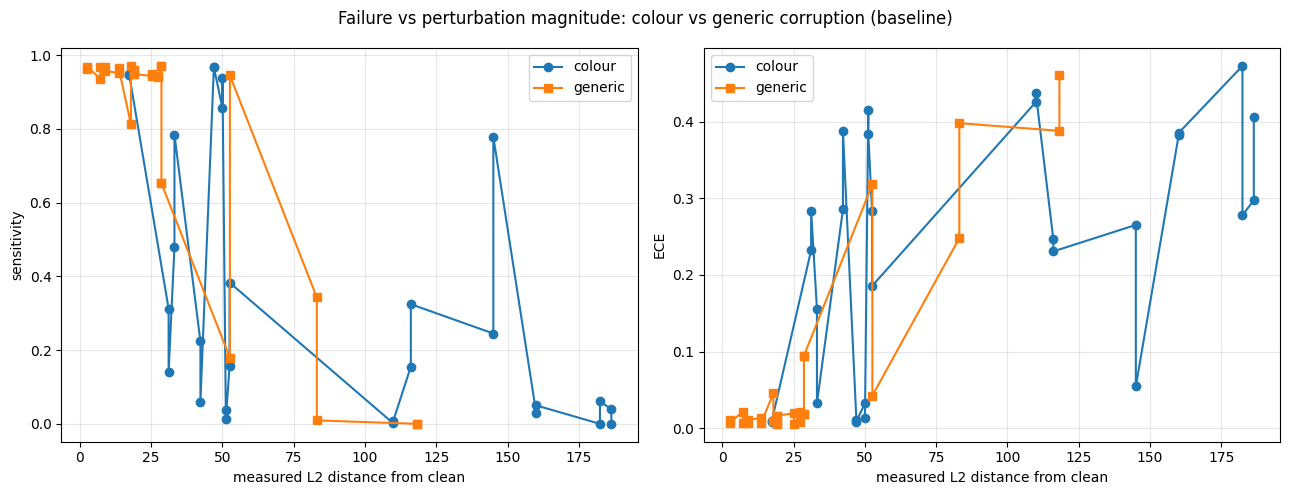

In [19]:
# ============ CELL C4b — measured severity on a common axis ============
def mean_l2(samples, pil_interv=None, tensor_interv=None, n=300, seed=GLOBAL_SEED):
    rng = random.Random(seed)
    sub = rng.sample(samples, min(n, len(samples)))
    rs = T.Resize((IMG_SIZE, IMG_SIZE)); tt = T.ToTensor()
    ds = []
    for s in sub:
        img = rs(Image.open(s["path"]).convert("RGB"))
        clean = tt(img)
        im = pil_interv(img) if pil_interv is not None else img
        t = tt(im)
        if tensor_interv is not None:
            t = tensor_interv(t.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
        ds.append(torch.norm(clean - t).item())
    return float(np.mean(ds)), float(np.std(ds))

sev = {}
for name, iv in PIL_INTERVENTIONS.items():    sev[name] = mean_l2(test_samples, pil_interv=iv)
for name, iv in TENSOR_INTERVENTIONS.items(): sev[name] = mean_l2(test_samples, tensor_interv=iv)
for name, iv in ABLATIONS.items():            sev[name] = mean_l2(test_samples, pil_interv=iv)
for name, iv in blur_sev.items():             sev[name] = mean_l2(test_samples, pil_interv=iv)
for name, iv in noise_sev.items():            sev[name] = mean_l2(test_samples, tensor_interv=iv)

sev_df = pd.DataFrame([{"condition": k, "l2_mean": v[0], "l2_std": v[1],
                        "family": ("generic" if ("blur" in k or "noise" in k) else "colour")}
                       for k, v in sev.items()]).sort_values("l2_mean")
sev_df.to_csv(os.path.join(WORK, "C4b_measured_severity.csv"), index=False)
print(sev_df.round(2).to_string(index=False))

perf = pd.concat([
    master_df[master_df.variant == "baseline"][["architecture","seed","condition","sensitivity","specificity","ece"]],
    abl_df[abl_df.variant == "baseline"][["architecture","seed","condition","sensitivity","specificity","ece"]],
    sweep_df[["architecture","seed","condition","sensitivity","specificity","ece"]],
], ignore_index=True)
sev_perf = (perf.merge(sev_df, on="condition", how="inner")
                .groupby(["architecture","condition","family","l2_mean"])
                [["sensitivity","specificity","ece"]].agg(["mean","std"]).reset_index())
sev_perf.columns = ["_".join(c).strip("_") for c in sev_perf.columns]
sev_perf = sev_perf.sort_values("l2_mean")
sev_perf.to_csv(os.path.join(WORK, "C4b_severity_vs_performance.csv"), index=False)
print("\n=== sensitivity and ECE vs MEASURED perturbation magnitude ===")
print(sev_perf.round(4).to_string(index=False))

print("\n=== matched-or-harder generic control for each colour condition ===")
gen = sev_perf[sev_perf.family == "generic"]
for _, r in sev_perf[sev_perf.family == "colour"].iterrows():
    harder = gen[gen.l2_mean >= r.l2_mean]
    if len(harder) == 0:
        print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f}  -> NO generic control this severe")
        continue
    w = harder.loc[harder.sensitivity_mean.idxmin()]
    ratio = w.sensitivity_mean / max(r.sensitivity_mean, 1e-6)
    print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f} | "
          f"worst generic at L2>={r.l2_mean:.0f}: {w.condition} (L2={w.l2_mean:.1f}) "
          f"sens={w.sensitivity_mean:.4f}  ratio={ratio:.1f}x")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for fam, mk in [("colour", "o"), ("generic", "s")]:
    d = sev_perf[sev_perf.family == fam].sort_values("l2_mean")
    ax[0].plot(d.l2_mean, d.sensitivity_mean, mk + "-", label=fam)
    ax[1].plot(d.l2_mean, d.ece_mean, mk + "-", label=fam)
ax[0].set_xlabel("measured L2 distance from clean"); ax[0].set_ylabel("sensitivity")
ax[1].set_xlabel("measured L2 distance from clean"); ax[1].set_ylabel("ECE")
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.suptitle("Failure vs perturbation magnitude: colour vs generic corruption (baseline)")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "C4b_severity_curve.png"), dpi=150); plt.show()

In [20]:
# ============ CELL C4c — corrected matched-control comparison ============
gen = sev_perf[sev_perf.family == "generic"].sort_values("l2_mean")
col = sev_perf[sev_perf.family == "colour"].sort_values("l2_mean")
rows = []
print("=== NEAREST-OR-HARDER generic control for each colour condition ===")
for _, r in col.iterrows():
    harder = gen[gen.l2_mean >= r.l2_mean]
    if len(harder) == 0:
        print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f}"
              f"  -> NO generic control this severe (claim not supportable)")
        rows.append({"colour_condition": r.condition, "colour_l2": r.l2_mean,
                     "colour_sens": r.sensitivity_mean, "generic_condition": None,
                     "generic_l2": np.nan, "generic_sens": np.nan,
                     "sens_ratio": np.nan, "l2_excess": np.nan})
        continue
    w = harder.iloc[0]                      # smallest L2 that is >= colour L2
    ratio = w.sensitivity_mean / max(r.sensitivity_mean, 1e-6)
    print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f} | "
          f"matched generic {w.condition} (L2={w.l2_mean:6.1f}, {w.l2_mean/r.l2_mean:.2f}x) "
          f"sens={w.sensitivity_mean:.4f}  ratio={ratio:6.1f}x")
    rows.append({"colour_condition": r.condition, "colour_l2": r.l2_mean,
                 "colour_sens": r.sensitivity_mean, "generic_condition": w.condition,
                 "generic_l2": w.l2_mean, "generic_sens": w.sensitivity_mean,
                 "sens_ratio": ratio, "l2_excess": w.l2_mean / r.l2_mean})
matched_df = pd.DataFrame(rows)
matched_df.to_csv(os.path.join(WORK, "C4c_matched_controls.csv"), index=False)

print("\n=== within-colour magnitude contrast (no cross-family matching needed) ===")
for a, b in [("channel_BGR", "grayscale"), ("channel_BGR", "hue_90"), ("channel_BGR", "channel_GRB")]:
    ra = sev_perf[sev_perf.condition == a].iloc[0]
    rb = sev_perf[sev_perf.condition == b].iloc[0]
    print(f"  {a} L2={ra.l2_mean:.1f} sens={ra.sensitivity_mean:.4f}  vs  "
          f"{b} L2={rb.l2_mean:.1f} sens={rb.sensitivity_mean:.4f}   "
          f"(larger perturbation, {ra.sensitivity_mean/max(rb.sensitivity_mean,1e-6):.0f}x higher sensitivity)")

print("\n=== where each family first breaks (sens < 0.50) ===")
for fam in ["generic", "colour"]:
    d = sev_perf[(sev_perf.family == fam) & (sev_perf.sensitivity_mean < 0.50)].sort_values("l2_mean")
    if len(d):
        print(f"  {fam:8s}: first failure at L2={d.iloc[0].l2_mean:.1f} ({d.iloc[0].condition})")
    else:
        print(f"  {fam:8s}: never falls below 0.50 in the tested range")

=== NEAREST-OR-HARDER generic control for each colour condition ===
  hue_30               L2=  17.3 sens=0.9481 | matched generic noise_std_0.05 (L2=  17.9, 1.03x) sens=0.8124  ratio=   0.9x
  hue_30               L2=  17.3 sens=0.9470 | matched generic noise_std_0.05 (L2=  17.9, 1.03x) sens=0.8124  ratio=   0.9x
  grayscale            L2=  31.1 sens=0.3122 | matched generic noise_std_0.15 (L2=  52.6, 1.69x) sens=0.1793  ratio=   0.6x
  grayscale            L2=  31.1 sens=0.1407 | matched generic noise_std_0.15 (L2=  52.6, 1.69x) sens=0.1793  ratio=   1.3x
  hue_60               L2=  33.2 sens=0.4794 | matched generic noise_std_0.15 (L2=  52.6, 1.59x) sens=0.1793  ratio=   0.4x
  hue_60               L2=  33.2 sens=0.7844 | matched generic noise_std_0.15 (L2=  52.6, 1.59x) sens=0.1793  ratio=   0.2x
  hue_90               L2=  42.3 sens=0.2234 | matched generic noise_std_0.15 (L2=  52.6, 1.24x) sens=0.1793  ratio=   0.8x
  hue_90               L2=  42.3 sens=0.0605 | matched generic n

In [21]:
# ============ CELL C4d — hue dose-response ============
hue_rows = sev_perf[sev_perf.condition.isin(["hue_30", "hue_60", "hue_90"])].sort_values("l2_mean")
print("=== hue rotation dose-response (baseline) ===")
print(hue_rows[["condition", "l2_mean", "sensitivity_mean", "sensitivity_std",
                "specificity_mean", "ece_mean"]].round(4).to_string(index=False))
print("\nclean reference: sens 0.9665, spec 0.9732, ece 0.0088")

=== hue rotation dose-response (baseline) ===
condition  l2_mean  sensitivity_mean  sensitivity_std  specificity_mean  ece_mean
   hue_30  17.3447            0.9481           0.0099            0.9793    0.0077
   hue_30  17.3447            0.9470           0.0066            0.9819    0.0093
   hue_60  33.1910            0.4794           0.1787            0.9918    0.1557
   hue_60  33.1910            0.7844           0.0947            0.9900    0.0327
   hue_90  42.3016            0.2234           0.1485            0.9949    0.2854
   hue_90  42.3016            0.0605           0.0208            0.9955    0.3877

clean reference: sens 0.9665, spec 0.9732, ece 0.0088


In [22]:
# ============ CELL C4e — fill the L2 28-52 generic gap ============
gap_rows = []
gap_blur = {f"blur_sigma_{s}": GaussianBlurControl(kernel_size=15, sigma=s) for s in [8.0, 11.0]}
gap_noise = {f"noise_std_{s}": GaussianNoiseControl(std=s) for s in [0.10, 0.12]}
for (arch, variant, seed), path in sorted(REG.items()):
    if variant != "baseline": continue
    m = load_model(arch, path)
    for name, iv in gap_blur.items():
        y, p = predict(m, test_samples, pil_interv=iv)
        r = {"architecture": arch, "seed": seed, "condition": name}; r.update(metric_pack(y, p))
        gap_rows.append(r)
    for name, iv in gap_noise.items():
        y, p = predict(m, test_samples, tensor_interv=iv)
        r = {"architecture": arch, "seed": seed, "condition": name}; r.update(metric_pack(y, p))
        gap_rows.append(r)
    del m; torch.cuda.empty_cache()
    print("gap-swept", seed, flush=True)

# ---- multi-architecture aggregation ----
gap_df = pd.DataFrame(gap_rows)
for name, iv in gap_blur.items():  sev[name] = mean_l2(test_samples, pil_interv=iv)
for name, iv in gap_noise.items(): sev[name] = mean_l2(test_samples, tensor_interv=iv)
gap_sev = pd.DataFrame([{"condition": k, "l2_mean": sev[k][0], "l2_std": sev[k][1],
                         "family": "generic"} for k in list(gap_blur) + list(gap_noise)])
print(gap_sev.round(2).to_string(index=False))
print(gap_df.groupby(["architecture", "condition"])
      [["accuracy", "sensitivity", "specificity", "auroc", "ece"]]
      .agg(["mean", "std"]).round(4).to_string())

sev_df2 = pd.concat([sev_df, gap_sev], ignore_index=True).drop_duplicates("condition")
perf2 = pd.concat([perf, gap_df[["architecture", "seed", "condition",
                                 "sensitivity", "specificity", "ece"]]], ignore_index=True)
sp2 = (perf2.merge(sev_df2, on="condition", how="inner")
            .groupby(["architecture", "condition", "family", "l2_mean"])
            [["sensitivity", "specificity", "ece"]].agg(["mean", "std"]).reset_index())
sp2.columns = ["_".join(c).strip("_") for c in sp2.columns]
sp2 = sp2.sort_values(["architecture", "l2_mean"])
sp2.to_csv(os.path.join(WORK, "C4e_severity_vs_performance_filled.csv"), index=False)

# Severity is a property of the DATA, so it is shared; sensitivity is per-architecture.
for arch in sorted(sp2.architecture.unique()):
    sa = sp2[sp2.architecture == arch]
    gen2 = sa[sa.family == "generic"].sort_values("l2_mean")
    print(f"\n=== matched controls after gap fill — {arch} ===")
    for _, r in sa[sa.family == "colour"].sort_values("l2_mean").iterrows():
        h = gen2[gen2.l2_mean >= r.l2_mean]
        if len(h) == 0:
            print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f} -> unmatched")
            continue
        w = h.iloc[0]
        print(f"  {r.condition:20s} L2={r.l2_mean:6.1f} sens={r.sensitivity_mean:.4f} | "
              f"{w.condition} (L2={w.l2_mean:6.1f}, {w.l2_mean/r.l2_mean:.2f}x) "
              f"sens={w.sensitivity_mean:.4f} ratio={w.sensitivity_mean/max(r.sensitivity_mean,1e-6):6.1f}x")
    print(f"--- first failure (sens < 0.50), {arch} ---")
    for fam in ["generic", "colour"]:
        sub = sa[(sa.family == fam) & (sa.sensitivity_mean < 0.50)].sort_values("l2_mean")
        if len(sub):
            print(f"  {fam:8s}: L2={sub.iloc[0].l2_mean:.1f} ({sub.iloc[0].condition})")
        else:
            print(f"  {fam:8s}: never fails in the swept range")

gap-swept 1
gap-swept 7
gap-swept 42
gap-swept 1
gap-swept 7
gap-swept 42
      condition  l2_mean  l2_std  family
 blur_sigma_8.0    30.24    2.37 generic
blur_sigma_11.0    30.93    2.42 generic
  noise_std_0.1    35.65    0.74 generic
 noise_std_0.12    42.55    0.91 generic
                             accuracy         sensitivity         specificity           auroc             ece        
                                 mean     std        mean     std        mean     std    mean     std    mean     std
architecture condition                                                                                               
mobilenetv3  blur_sigma_11.0   0.9536  0.0010      0.9289  0.0040      0.9780  0.0056  0.9896  0.0010  0.0226  0.0011
             blur_sigma_8.0    0.9539  0.0013      0.9310  0.0027      0.9766  0.0049  0.9898  0.0010  0.0213  0.0006
             noise_std_0.1     0.7442  0.1378      0.4895  0.2823      0.9955  0.0050  0.9329  0.0347  0.1578  0.1053
             

In [23]:
# ============ CELL C5 — temperature scaling and calibration ============
def fit_temperature(model, samples, base_tf=EVAL_TF_PLAIN, pil_interv=None, tensor_interv=None,
                    max_iter=200):
    tf_list = [T.Resize((IMG_SIZE, IMG_SIZE))]
    if base_tf is EVAL_TF_GRAY:  tf_list.append(T.Grayscale(num_output_channels=3))
    if base_tf is EVAL_TF_GREEN: tf_list.append(T.Lambda(lambda im: GreenOnly()(im)))
    if pil_interv is not None:   tf_list.append(T.Lambda(lambda im: pil_interv(im)))
    tf_list.append(T.ToTensor())
    loader = make_loader(samples, T.Compose(tf_list), shuffle=False)
    model.eval()
    LG, LB = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            if tensor_interv is not None: imgs = tensor_interv(imgs)
            LG.append(model(normalize_batch(imgs)).float().cpu()); LB.append(labels)
    logits = torch.cat(LG); labels = torch.cat(LB)
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=max_iter)
    crit = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad()
        loss = crit(logits / logT.exp(), labels)
        loss.backward(); return loss
    opt.step(closure)
    return float(logT.exp().item()), logits, labels

def probs_at_T(logits, T_):
    return torch.softmax(logits / T_, dim=1)[:, 1].numpy()

def _fit_T_on(logits, labels, max_iter=200):
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=max_iter)
    crit = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad(); loss = crit(logits / logT.exp(), labels); loss.backward(); return loss
    opt.step(closure)
    return float(logT.exp().item())

CAL_CONDS = [("clean", None, None),
             ("grayscale", PIL_INTERVENTIONS["grayscale"], None),
             ("hue_90", PIL_INTERVENTIONS["hue_90"], None),
             ("channel_GRB", PIL_INTERVENTIONS["channel_GRB"], None),
             ("noise_std_0.15", None, GaussianNoiseControl(std=0.15))]

cal_rows = []
for arch in ARCHS:
    for variant in ["baseline", "colour_plus_blur"]:
        for seed in SEEDS:
            path = ckpt_path(arch, variant, seed)
            if not os.path.exists(path):
                continue
            m = load_model(arch, path)
            T_clean, _, _ = fit_temperature(m, val_samples)   # deployment-realistic
            for cname, pil_i, ten_i in CAL_CONDS:
                _, logits, labels = fit_temperature(m, test_samples,
                                                    pil_interv=pil_i, tensor_interv=ten_i)
                y = labels.numpy()
                r_raw = metric_pack(y, probs_at_T(logits, 1.0))
                r_cal = metric_pack(y, probs_at_T(logits, T_clean))
                T_oracle = _fit_T_on(logits, labels)          # unavailable upper bound
                r_or = metric_pack(y, probs_at_T(logits, T_oracle))
                cal_rows.append({"architecture": arch, "variant": variant, "seed": seed,
                                 "condition": cname, "T_clean": T_clean, "T_oracle": T_oracle,
                                 "ece_raw": r_raw["ece"], "ece_clean_T": r_cal["ece"],
                                 "ece_oracle_T": r_or["ece"],
                                 "brier_raw": r_raw["brier"], "brier_clean_T": r_cal["brier"],
                                 "brier_oracle_T": r_or["brier"],
                                 "sens_raw": r_raw["sensitivity"],
                                 "sens_clean_T": r_cal["sensitivity"],
                                 "sens_oracle_T": r_or["sensitivity"],
                                 "auroc": r_raw["auroc"]})
            del m; torch.cuda.empty_cache()
            print("calibrated", arch, variant, seed, flush=True)

cal_df = pd.DataFrame(cal_rows)
cal_df.to_csv(os.path.join(WORK, "C5_calibration.csv"), index=False)
print("\n=== calibration: raw vs clean-fitted T vs oracle T ===")
print(cal_df.groupby(["architecture", "variant", "condition"])
      [["T_clean", "T_oracle", "ece_raw", "ece_clean_T", "ece_oracle_T",
        "sens_raw", "sens_oracle_T", "auroc"]].agg(["mean", "std"]).round(4).to_string())
print("\nNOTE: temperature scaling is DECISION-INVARIANT for two classes at a 0.5 "
      "threshold, so sens_raw == sens_oracle_T by construction. Verify this holds.", flush=True)

calibrated resnet18 baseline 42
calibrated resnet18 baseline 1
calibrated resnet18 baseline 7
calibrated resnet18 colour_plus_blur 42
calibrated resnet18 colour_plus_blur 1
calibrated resnet18 colour_plus_blur 7
calibrated mobilenetv3 baseline 42
calibrated mobilenetv3 baseline 1
calibrated mobilenetv3 baseline 7
calibrated mobilenetv3 colour_plus_blur 42
calibrated mobilenetv3 colour_plus_blur 1
calibrated mobilenetv3 colour_plus_blur 7

=== calibration: raw vs clean-fitted T vs oracle T ===
                                             T_clean         T_oracle          ece_raw         ece_clean_T         ece_oracle_T         sens_raw         sens_oracle_T           auroc        
                                                mean     std     mean      std    mean     std        mean     std         mean     std     mean     std          mean     std    mean     std
architecture variant          condition                                                                                 

In [24]:
# ============ CELL C0b — case-level (clustered) bootstrap ============
import numpy as np

def case_bootstrap_ci(labels, probs, cases, fn, n_boot=2000, alpha=0.05, seed=0):
    """Resample CASES with replacement, not images."""
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels); probs = np.asarray(probs); cases = np.asarray(cases)
    uniq = np.unique(cases)
    idx_by_case = {c: np.where(cases == c)[0] for c in uniq}
    stats = []
    for _ in range(n_boot):
        drawn = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([idx_by_case[c] for c in drawn])
        if len(np.unique(labels[idx])) < 2:
            continue
        try:
            stats.append(fn(labels[idx], probs[idx]))
        except Exception:
            continue
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(np.mean(stats)), float(lo), float(hi), len(stats)

test_cases = np.array([s["case"] for s in test_samples])
print("test cases:", len(np.unique(test_cases)), flush=True)

acc_fn  = lambda y, p: float(((p >= 0.5).astype(int) == y).mean())
sens_fn = lambda y, p: float(((p >= 0.5).astype(int)[y == 1] == 1).mean())

ci_rows = []
for arch in ARCHS:
    for variant in ["baseline", "colour_plus_blur"]:
        for seed in SEEDS:
            path = ckpt_path(arch, variant, seed)
            if not os.path.exists(path):
                continue
            m = load_model(arch, path)
            for cname, pil_i in [("clean", None), ("grayscale", PIL_INTERVENTIONS["grayscale"])]:
                y, p = predict(m, test_samples, pil_interv=pil_i)
                for mname, f in [("accuracy", acc_fn), ("sensitivity", sens_fn)]:
                    mu, lo, hi, nb = case_bootstrap_ci(y, p, test_cases, f, seed=seed)
                    rng = np.random.default_rng(seed)
                    ist = [f(y[i], p[i]) for i in
                           (rng.integers(0, len(y), len(y)) for _ in range(2000))
                           if len(np.unique(y[i])) > 1]
                    ilo, ihi = np.percentile(ist, [2.5, 97.5])
                    ci_rows.append({"architecture": arch, "variant": variant, "seed": seed,
                                    "condition": cname, "metric": mname, "case_mean": mu,
                                    "case_lo": lo, "case_hi": hi, "case_width": hi - lo,
                                    "img_lo": float(ilo), "img_hi": float(ihi),
                                    "img_width": float(ihi - ilo),
                                    "inflation": (hi - lo) / max(ihi - ilo, 1e-9),
                                    "n_boot_valid": nb})
            del m; torch.cuda.empty_cache()
            print("bootstrapped", arch, variant, seed, flush=True)

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(os.path.join(WORK, "C0b_case_level_ci.csv"), index=False)
print(ci_df.groupby(["architecture", "variant", "condition", "metric"])
      [["case_mean", "case_lo", "case_hi", "case_width", "img_width", "inflation"]]
      .mean().round(4).to_string())

test cases: 30
bootstrapped resnet18 baseline 42
bootstrapped resnet18 baseline 1
bootstrapped resnet18 baseline 7
bootstrapped resnet18 colour_plus_blur 42
bootstrapped resnet18 colour_plus_blur 1
bootstrapped resnet18 colour_plus_blur 7
bootstrapped mobilenetv3 baseline 42
bootstrapped mobilenetv3 baseline 1
bootstrapped mobilenetv3 baseline 7
bootstrapped mobilenetv3 colour_plus_blur 42
bootstrapped mobilenetv3 colour_plus_blur 1
bootstrapped mobilenetv3 colour_plus_blur 7
                                                     case_mean  case_lo  case_hi  case_width  img_width  inflation
architecture variant          condition metric                                                                    
mobilenetv3  baseline         clean     accuracy        0.9695   0.9619   0.9774      0.0155     0.0103     1.4941
                                        sensitivity     0.9634   0.9468   0.9771      0.0303     0.0159     1.8957
                              grayscale accuracy        0.6

In [25]:
# ============ CELL C5b — oracle threshold: threshold artifact vs information loss ============
def oracle_threshold_metrics(y, p, spec_floor=0.95):
    ths = np.unique(np.concatenate([[0.0, 1.0], np.quantile(p, np.linspace(0, 1, 501))]))
    best_j, best = -2.0, {}
    feasible = []
    for t in ths:
        pred = (p >= t).astype(int)
        tp = ((pred == 1) & (y == 1)).sum(); fn_ = ((pred == 0) & (y == 1)).sum()
        tn = ((pred == 0) & (y == 0)).sum(); fp = ((pred == 1) & (y == 0)).sum()
        sens = tp / max(tp + fn_, 1); spec = tn / max(tn + fp, 1)
        j = sens + spec - 1
        if j > best_j:
            best_j, best = j, {"th_youden": float(t), "sens_youden": float(sens),
                               "spec_youden": float(spec), "youden_j": float(j),
                               "acc_youden": float((pred == y).mean())}
        if spec >= spec_floor:
            feasible.append((sens, float(t), float(spec)))
    if feasible:
        s, t, sp = max(feasible)
        best.update({"sens_at_spec95": s, "th_at_spec95": t, "spec_at_spec95": sp})
    else:
        best.update({"sens_at_spec95": float("nan"), "th_at_spec95": float("nan"),
                     "spec_at_spec95": float("nan")})
    return best

OT_CONDS = CAL_CONDS

ot_rows = []
for arch in ARCHS:
    for variant in ["baseline", "colour_plus_blur"]:
        for seed in SEEDS:
            path = ckpt_path(arch, variant, seed)
            if not os.path.exists(path):
                continue
            m = load_model(arch, path)
            for cname, pil_i, ten_i in OT_CONDS:
                y, p = predict(m, test_samples, pil_interv=pil_i, tensor_interv=ten_i)
                r = {"architecture": arch, "variant": variant, "seed": seed, "condition": cname}
                r.update(metric_pack(y, p))
                r.update(oracle_threshold_metrics(np.asarray(y), np.asarray(p)))
                ot_rows.append(r)
            del m; torch.cuda.empty_cache()
            print("oracle-thresholded", arch, variant, seed, flush=True)

ot_df = pd.DataFrame(ot_rows)
ot_df.to_csv(os.path.join(WORK, "C5b_oracle_threshold.csv"), index=False)
print("\n=== default 0.5 threshold vs ORACLE threshold on the shifted data ===")
print(ot_df.groupby(["architecture", "variant", "condition"])
      [["sensitivity", "specificity", "auroc", "sens_youden", "spec_youden",
        "th_youden", "sens_at_spec95"]].agg(["mean", "std"]).round(4).to_string())

print("\n=== recoverable fraction of the sensitivity loss (baseline) ===")
for arch in sorted(ot_df.architecture.unique()):
    b = (ot_df[(ot_df.variant == "baseline") & (ot_df.architecture == arch)]
         .groupby("condition")[["sensitivity", "sens_youden"]].mean())
    if "clean" not in b.index:
        continue
    clean_sens = b.loc["clean", "sensitivity"]
    print(f"  --- {arch} (clean sens {clean_sens:.4f}) ---")
    for c in b.index:
        if c == "clean":
            continue
        lost = clean_sens - b.loc[c, "sensitivity"]
        rec = b.loc[c, "sens_youden"] - b.loc[c, "sensitivity"]
        frac = 100 * rec / lost if lost > 0.10 else float("nan")
        print(f"    {c:16s} lost {lost:.4f}, oracle threshold recovers {rec:.4f} "
              f"({frac:5.1f}%), residual {lost-rec:.4f}")

oracle-thresholded resnet18 baseline 42
oracle-thresholded resnet18 baseline 1
oracle-thresholded resnet18 baseline 7
oracle-thresholded resnet18 colour_plus_blur 42
oracle-thresholded resnet18 colour_plus_blur 1
oracle-thresholded resnet18 colour_plus_blur 7
oracle-thresholded mobilenetv3 baseline 42
oracle-thresholded mobilenetv3 baseline 1
oracle-thresholded mobilenetv3 baseline 7
oracle-thresholded mobilenetv3 colour_plus_blur 42
oracle-thresholded mobilenetv3 colour_plus_blur 1
oracle-thresholded mobilenetv3 colour_plus_blur 7

=== default 0.5 threshold vs ORACLE threshold on the shifted data ===
                                             sensitivity         specificity           auroc         sens_youden         spec_youden         th_youden         sens_at_spec95        
                                                    mean     std        mean     std    mean     std        mean     std        mean     std      mean     std           mean     std
architecture variant       

In [26]:
# ============ CELL C5c — recovery under a specificity floor ============
def sens_at_floor(y, p, floor):
    ths = np.unique(np.concatenate([[0.0, 1.0], np.quantile(p, np.linspace(0, 1, 1001))]))
    best = float("nan")
    for t in ths:
        pred = (p >= t).astype(int)
        tn = ((pred == 0) & (y == 0)).sum(); fp = ((pred == 1) & (y == 0)).sum()
        if tn / max(tn + fp, 1) >= floor:
            tp = ((pred == 1) & (y == 1)).sum(); fn_ = ((pred == 0) & (y == 1)).sum()
            s = tp / max(tp + fn_, 1)
            if not (s <= best):
                best = float(s)
    return best

FLOORS = [0.90, 0.95, 0.98]
rec_rows = []
for arch in ARCHS:
    for variant in ["baseline", "colour_plus_blur"]:
        for seed in SEEDS:
            path = ckpt_path(arch, variant, seed)
            if not os.path.exists(path):
                continue
            m = load_model(arch, path)
            cache = {}
            for cname, pil_i, ten_i in OT_CONDS:
                y, p = predict(m, test_samples, pil_interv=pil_i, tensor_interv=ten_i)
                cache[cname] = (np.asarray(y), np.asarray(p))
            yc, pc = cache["clean"]
            for cname, (y, p) in cache.items():
                row = {"architecture": arch, "variant": variant, "seed": seed,
                       "condition": cname,
                       "sens_default": float(((p >= 0.5).astype(int)[y == 1] == 1).mean())}
                for fl in FLOORS:
                    s_shift = sens_at_floor(y, p, fl)
                    s_clean = sens_at_floor(yc, pc, fl)
                    lost = s_clean - row["sens_default"]
                    rec = s_shift - row["sens_default"]
                    row[f"sens_at_spec{int(fl*100)}"] = s_shift
                    row[f"recovered_frac_spec{int(fl*100)}"] = (
                        rec / lost if lost > 0.10 else float("nan"))
                rec_rows.append(row)
            del m; torch.cuda.empty_cache()
            print("floor-analysed", arch, variant, seed, flush=True)

rec_df = pd.DataFrame(rec_rows)
rec_df.to_csv(os.path.join(WORK, "C5c_specificity_floor_recovery.csv"), index=False)
cols = ["sens_default"] + [f"sens_at_spec{int(f*100)}" for f in FLOORS] \
       + [f"recovered_frac_spec{int(f*100)}" for f in FLOORS]
print(rec_df.groupby(["architecture", "variant", "condition"])[cols]
      .agg(["mean", "std"]).round(4).to_string())

floor-analysed resnet18 baseline 42
floor-analysed resnet18 baseline 1
floor-analysed resnet18 baseline 7
floor-analysed resnet18 colour_plus_blur 42
floor-analysed resnet18 colour_plus_blur 1
floor-analysed resnet18 colour_plus_blur 7
floor-analysed mobilenetv3 baseline 42
floor-analysed mobilenetv3 baseline 1
floor-analysed mobilenetv3 baseline 7
floor-analysed mobilenetv3 colour_plus_blur 42
floor-analysed mobilenetv3 colour_plus_blur 1
floor-analysed mobilenetv3 colour_plus_blur 7
                                             sens_default         sens_at_spec90         sens_at_spec95         sens_at_spec98         recovered_frac_spec90         recovered_frac_spec95         recovered_frac_spec98        
                                                     mean     std           mean     std           mean     std           mean     std                  mean     std                  mean     std                  mean     std
architecture variant          condition                     

In [27]:
# ============ CELL C6 — BBBC041 download + lazy square-crop records ============
BB_DIR  = os.path.join(WORK, "bbbc041")
BB_ROOT = os.path.join(BB_DIR, "malaria")

if not os.path.exists(os.path.join(BB_ROOT, "training.json")):
    os.makedirs(BB_DIR, exist_ok=True)
    rc = os.system("wget -q --tries=3 --timeout=90 "
                   "https://data.broadinstitute.org/bbbc/BBBC041/malaria.zip "
                   f"-O {BB_DIR}/malaria.zip")
    assert rc == 0, "download failed — enable Internet in notebook settings"
    rc = os.system(f"cd {BB_DIR} && unzip -q -o malaria.zip")
    assert rc == 0, "unzip failed"
print("BB_ROOT contents:", sorted(os.listdir(BB_ROOT))[:8], flush=True)

UNINF = {"red blood cell", "leukocyte"}
INF   = {"trophozoite", "ring", "schizont", "gametocyte"}
# NOTE: BBBC041 also has a 'difficult' category. It is excluded from both classes
# because its infection status is not reliably determined. Report the count.

def square_box(r0, c0, r1, c1, H, W):
    """Expand to a square about the centre, clamped inside the image, so the
       resize to 224 does not distort aspect ratio."""
    h, w = r1 - r0, c1 - c0
    side = min(max(h, w), H, W)
    cr, cc = (r0 + r1) / 2.0, (c0 + c1) / 2.0
    nr0 = max(0, min(int(round(cr - side / 2)), H - side))
    nc0 = max(0, min(int(round(cc - side / 2)), W - side))
    return nr0, nc0, nr0 + side, nc0 + side

def build_records(json_name, split_tag):
    recs = json.load(open(os.path.join(BB_ROOT, json_name)))
    out, cat_counts, missing = [], {}, 0
    for rec in recs:
        ip = BB_ROOT + rec["image"]["pathname"]
        if not os.path.exists(ip):
            missing += 1
            continue
        shp = rec["image"]["shape"]
        H, W = shp["r"], shp["c"]
        img_id = os.path.basename(rec["image"]["pathname"]).rsplit(".", 1)[0]
        for i, obj in enumerate(rec["objects"]):
            cat = obj["category"]
            cat_counts[cat] = cat_counts.get(cat, 0) + 1
            if   cat in UNINF: lab = 0
            elif cat in INF:   lab = 1
            else:              continue
            b = obj["bounding_box"]
            box = square_box(b["minimum"]["r"], b["minimum"]["c"],
                             b["maximum"]["r"], b["maximum"]["c"], H, W)
            out.append({"path": ip, "box": box, "label": lab, "category": cat,
                        "image_id": img_id, "obj": i, "split_tag": split_tag})
    return out, cat_counts, missing

bb_recs, cc_a, miss_a = build_records("training.json", "train")
_r2, cc_b, miss_b = build_records("test.json", "test")
bb_recs += _r2
for k, v in cc_b.items():
    cc_a[k] = cc_a.get(k, 0) + v

print("missing image files:", miss_a + miss_b, flush=True)
print("annotation categories (ALL, before class mapping):")
for k in sorted(cc_a, key=lambda x: -cc_a[x]):
    tag = "uninf" if k in UNINF else ("INF" if k in INF else "EXCLUDED")
    print(f"  {k:20s} {cc_a[k]:7d}   {tag}")
n_pos = sum(r["label"] for r in bb_recs)
print(f"\nusable cells: {len(bb_recs)} | positive {n_pos} ({100*n_pos/len(bb_recs):.2f}%)")
print("source slide images:", len({r['image_id'] for r in bb_recs}), flush=True)

class BBCropDataset(Dataset):
    """Crops on the fly. Same output contract as MalariaDataset."""
    def __init__(self, records, transform):
        self.recs = records; self.transform = transform
    def __len__(self):
        return len(self.recs)
    def __getitem__(self, idx):
        r = self.recs[idx]
        img = Image.open(r["path"]).convert("RGB")
        r0, c0, r1, c1 = r["box"]
        return self.transform(img.crop((c0, r0, c1, r1))), r["label"]

def predict_bb(model, records, base_tf=EVAL_TF_PLAIN, pil_interv=None,
               tensor_interv=None, bs=BATCH_SIZE):
    tf_list = [T.Resize((IMG_SIZE, IMG_SIZE))]
    if base_tf is EVAL_TF_GRAY:  tf_list.append(T.Grayscale(num_output_channels=3))
    if base_tf is EVAL_TF_GREEN: tf_list.append(T.Lambda(lambda im: GreenOnly()(im)))
    if pil_interv is not None:   tf_list.append(T.Lambda(lambda im: pil_interv(im)))
    tf_list.append(T.ToTensor())
    g = torch.Generator(); g.manual_seed(GLOBAL_SEED)
    loader = DataLoader(BBCropDataset(records, T.Compose(tf_list)), batch_size=bs,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
                        worker_init_fn=seed_worker, generator=g,
                        persistent_workers=(NUM_WORKERS > 0))
    model.eval()
    L, P = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            if tensor_interv is not None: imgs = tensor_interv(imgs)
            probs = torch.softmax(model(normalize_batch(imgs)), dim=1)[:, 1]
            L.append(labels.numpy()); P.append(probs.float().cpu().numpy())
    return np.concatenate(L), np.concatenate(P)

# smoke test: one batch through one model
_m = load_model("resnet18", ckpt_path("resnet18", "baseline", 42))
_y, _p = predict_bb(_m, bb_recs[:256])
print(f"BBBC041 smoke test OK — {len(_p)} preds, prob range [{_p.min():.3f}, {_p.max():.3f}], "
      f"labels {np.bincount(_y)}", flush=True)
del _m; torch.cuda.empty_cache()

BB_ROOT contents: ['images', 'test.json', 'training.json']
missing image files: 0
annotation categories (ALL, before class mapping):
  red blood cell         83034   uninf
  trophozoite             1584   INF
  ring                     522   INF
  difficult                446   EXCLUDED
  schizont                 190   INF
  gametocyte               156   INF
  leukocyte                103   uninf

usable cells: 85589 | positive 2452 (2.86%)
source slide images: 1328
BBBC041 smoke test OK — 256 preds, prob range [0.000, 0.980], labels [250   6]


In [28]:
# ============ CELL C7 — BBBC041 eval sets, split BY SLIDE IMAGE ============
u_all = [r for r in bb_recs if r["label"] == 0]
i_all = [r for r in bb_recs if r["label"] == 1]
u_rbc = [r for r in u_all if r["category"] == "red blood cell"]
print(f"uninfected {len(u_all)} (RBC only {len(u_rbc)}) | infected {len(i_all)}", flush=True)

rng = random.Random(GLOBAL_SEED)
bb_sets = {
    "full_prevalence":     u_all + i_all,
    "full_prevalence_rbc": u_rbc + i_all,
    "balanced":            rng.sample(u_all, len(i_all)) + i_all,
}
for k, v in bb_sets.items():
    pos = sum(r["label"] for r in v)
    print(f"{k}: {len(v)} cells, {pos} positive ({100*pos/len(v):.2f}%), "
          f"{len({r['image_id'] for r in v})} slides")

# Calibration / held-out halves split BY SLIDE, never by cell, so the threshold
# fitted in C9 is not tuned on cells from slides it is later evaluated on.
slides = sorted({r["image_id"] for r in bb_recs})
slide_pos = {s: 0 for s in slides}
for r in bb_recs:
    if r["label"] == 1:
        slide_pos[r["image_id"]] = 1
calib_sl, held_sl = train_test_split(slides, test_size=0.5, random_state=GLOBAL_SEED,
                                     stratify=[slide_pos[s] for s in slides])
calib_sl, held_sl = set(calib_sl), set(held_sl)
assert not (calib_sl & held_sl)

BB_CALIB = [r for r in bb_recs if r["image_id"] in calib_sl]
BB_HELD  = [r for r in bb_recs if r["image_id"] in held_sl]
for nm, ss in [("calibration", BB_CALIB), ("held-out", BB_HELD)]:
    pos = sum(r["label"] for r in ss)
    print(f"target-domain {nm}: {len(ss)} cells / {len({r['image_id'] for r in ss})} slides, "
          f"{pos} positive ({100*pos/len(ss):.2f}%)")

uninfected 83137 (RBC only 83034) | infected 2452
full_prevalence: 85589 cells, 2452 positive (2.86%), 1328 slides
full_prevalence_rbc: 85486 cells, 2452 positive (2.87%), 1328 slides
balanced: 4904 cells, 2452 positive (50.00%), 1242 slides
target-domain calibration: 42474 cells / 664 slides, 1231 positive (2.90%)
target-domain held-out: 43115 cells / 664 slides, 1221 positive (2.83%)


In [29]:
# ============ CELL C7b — difficult-category records + cached crop dataset ============
def build_difficult():
    out = []
    for jn, tag in [("training.json", "train"), ("test.json", "test")]:
        for rec in json.load(open(os.path.join(BB_ROOT, jn))):
            ip = BB_ROOT + rec["image"]["pathname"]
            if not os.path.exists(ip):
                continue
            H, W = rec["image"]["shape"]["r"], rec["image"]["shape"]["c"]
            img_id = os.path.basename(rec["image"]["pathname"]).rsplit(".", 1)[0]
            for i, obj in enumerate(rec["objects"]):
                if obj["category"] != "difficult":
                    continue
                b = obj["bounding_box"]
                out.append({"path": ip,
                            "box": square_box(b["minimum"]["r"], b["minimum"]["c"],
                                              b["maximum"]["r"], b["maximum"]["c"], H, W),
                            "label": -1, "category": "difficult",
                            "image_id": img_id, "obj": i, "split_tag": tag})
    return out

bb_diff = build_difficult()
print("difficult cells:", len(bb_diff), flush=True)

# Single ordered evaluation list. Sorting by path makes consecutive items share a slide.
BB_ALL = sorted(bb_recs + bb_diff, key=lambda r: (r["path"], r["obj"]))
BB_INDEX = {(r["image_id"], r["obj"]): k for k, r in enumerate(BB_ALL)}
print("BB_ALL:", len(BB_ALL), "| labelled:", sum(1 for r in BB_ALL if r["label"] >= 0), flush=True)

class BBCachedDataset(Dataset):
    """Crops lazily, caching the last decoded slide per worker. With path-sorted
       records this decodes each slide roughly once instead of once per cell."""
    def __init__(self, records, transform):
        self.recs = records; self.transform = transform
        self._key = None; self._img = None
    def __len__(self):
        return len(self.recs)
    def __getitem__(self, idx):
        r = self.recs[idx]
        if r["path"] != self._key:
            self._img = Image.open(r["path"]).convert("RGB")
            self._key = r["path"]
        r0, c0, r1, c1 = r["box"]
        return self.transform(self._img.crop((c0, r0, c1, r1))), max(r["label"], 0)

def predict_bb_all(model, records, bs=BATCH_SIZE):
    """Returns probabilities in the SAME ORDER as `records`."""
    g = torch.Generator(); g.manual_seed(GLOBAL_SEED)
    loader = DataLoader(BBCachedDataset(records, EVAL_TF_PLAIN), batch_size=bs,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
                        worker_init_fn=seed_worker, generator=g,
                        persistent_workers=False)
    model.eval()
    P = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            P.append(torch.softmax(model(normalize_batch(imgs)), dim=1)[:, 1]
                     .float().cpu().numpy())
    return np.concatenate(P)

import time as _time
_m = load_model("resnet18", ckpt_path("resnet18", "baseline", 42))
_t0 = _time.time(); _pp = predict_bb_all(_m, BB_ALL[:4096])
print(f"timing: 4096 crops in {_time.time()-_t0:.1f}s -> full set "
      f"~{(_time.time()-_t0)*len(BB_ALL)/4096/60:.1f} min/model", flush=True)
del _m; torch.cuda.empty_cache()

difficult cells: 446
BB_ALL: 86035 | labelled: 85589
timing: 4096 crops in 6.7s -> full set ~2.4 min/model


In [30]:
# ============ CELL C8 — cross-site metrics (one pass per model, AUPRC first) ============
LAB   = np.array([r["label"] for r in BB_ALL])
SLIDE = np.array([r["image_id"] for r in BB_ALL])
CAT   = np.array([r["category"] for r in BB_ALL])

idx_lab  = np.where(LAB >= 0)[0]
idx_diff = np.where(LAB < 0)[0]
idx_rbc  = np.where((LAB >= 0) & (CAT != "leukocyte"))[0]
_bal_keys = {(r["image_id"], r["obj"]) for r in bb_sets["balanced"]}
idx_bal  = np.array(sorted(BB_INDEX[k] for k in _bal_keys))
EVAL_IDX = {"full_prevalence": idx_lab, "full_prevalence_rbc": idx_rbc, "balanced": idx_bal}
for k, v in EVAL_IDX.items():
    print(f"{k}: n={len(v)} prevalence={LAB[v].mean():.4f}", flush=True)
print("chance-level AUPRC on full_prevalence =", round(float(LAB[idx_lab].mean()), 4), flush=True)

def slide_bootstrap(labels, probs, slides, fn, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    uniq = np.unique(slides)
    by = {s: np.where(slides == s)[0] for s in uniq}
    out = []
    for _ in range(n_boot):
        drawn = rng.choice(uniq, size=len(uniq), replace=True)
        i = np.concatenate([by[s] for s in drawn])
        if len(np.unique(labels[i])) < 2:
            continue
        try: out.append(fn(labels[i], probs[i]))
        except Exception: pass
    if not out:
        return float("nan"), float("nan")
    lo, hi = np.percentile(out, [2.5, 97.5])
    return float(lo), float(hi)

cs_rows, diff_rows = [], []
for arch in ARCHS:
    for variant in ["baseline", "colour_only", "colour_plus_blur"]:
        for seed in SEEDS:
            path = ckpt_path(arch, variant, seed)
            if not os.path.exists(path):
                continue
            m = load_model(arch, path)
            t0 = _time.time()
            probs = predict_bb_all(m, BB_ALL)
            np.savez_compressed(
                os.path.join(WORK, f"C8_probs__{arch}__{variant}__seed{seed}.npz"),
                probs=probs, labels=LAB, slide=SLIDE, category=CAT)
            for set_name, ix in EVAL_IDX.items():
                y, p = LAB[ix], probs[ix]
                r = {"architecture": arch, "variant": variant, "seed": seed,
                     "eval_set": set_name, "n": len(ix), "prevalence": float(y.mean())}
                r.update(metric_pack(y, p))
                lo, hi = slide_bootstrap(y, p, SLIDE[ix],
                                         lambda l, q: float(average_precision_score(l, q)),
                                         seed=seed)
                r["auprc_ci_lo"], r["auprc_ci_hi"] = lo, hi
                cs_rows.append(r)
            pd_ = probs[idx_diff]
            y_full, p_full = LAB[idx_lab], probs[idx_lab]
            y_incl = np.concatenate([y_full, np.ones(len(idx_diff), dtype=int)])
            p_incl = np.concatenate([p_full, pd_])
            diff_rows.append({
                "architecture": arch, "variant": variant, "seed": seed,
                "diff_mean_prob": float(pd_.mean()),
                "diff_frac_called_positive": float((pd_ >= 0.5).mean()),
                "neg_mean_prob": float(p_full[y_full == 0].mean()),
                "pos_mean_prob": float(p_full[y_full == 1].mean()),
                "auprc_excluded": float(average_precision_score(y_full, p_full)),
                "auprc_diff_as_pos": float(average_precision_score(y_incl, p_incl))})
            del m; torch.cuda.empty_cache()
            print(f"cross-site {arch} {variant} seed{seed} in "
                  f"{(_time.time()-t0)/60:.1f} min", flush=True)

cs_df = pd.DataFrame(cs_rows); cs_df.to_csv(os.path.join(WORK, "C8_cross_site.csv"), index=False)
diff_df = pd.DataFrame(diff_rows); diff_df.to_csv(os.path.join(WORK, "C8_difficult.csv"), index=False)

print("\n=== CROSS-SITE, CROSS-SPECIES (BBBC041, P. vivax) — AUPRC leads ===")
print(cs_df.groupby(["architecture", "variant", "eval_set"])
      [["auprc", "auprc_ci_lo", "auprc_ci_hi", "auroc", "prec_at_sens90",
        "sensitivity", "specificity", "ece"]].agg(["mean", "std"]).round(4).to_string())
print("\n=== 'difficult' category (excluded from all labelled metrics) ===")
print(diff_df.groupby(["architecture", "variant"])
      [["neg_mean_prob", "diff_mean_prob", "pos_mean_prob", "diff_frac_called_positive",
        "auprc_excluded", "auprc_diff_as_pos"]].agg(["mean", "std"]).round(4).to_string())
print("\nNOTE: accuracy is NOT reported — at 2.86% prevalence an all-negative "
      "classifier scores 0.9714.", flush=True)

full_prevalence: n=85589 prevalence=0.0286
full_prevalence_rbc: n=85486 prevalence=0.0287
balanced: n=4904 prevalence=0.5000
chance-level AUPRC on full_prevalence = 0.0286
cross-site resnet18 baseline seed42 in 2.3 min
cross-site resnet18 baseline seed1 in 2.3 min
cross-site resnet18 baseline seed7 in 2.3 min
cross-site resnet18 colour_only seed42 in 2.4 min
cross-site resnet18 colour_only seed1 in 2.3 min
cross-site resnet18 colour_only seed7 in 2.3 min
cross-site resnet18 colour_plus_blur seed42 in 2.3 min
cross-site resnet18 colour_plus_blur seed1 in 2.3 min
cross-site resnet18 colour_plus_blur seed7 in 2.3 min
cross-site mobilenetv3 baseline seed42 in 2.3 min
cross-site mobilenetv3 baseline seed1 in 2.3 min
cross-site mobilenetv3 baseline seed7 in 2.3 min
cross-site mobilenetv3 colour_only seed42 in 2.4 min
cross-site mobilenetv3 colour_only seed1 in 2.3 min
cross-site mobilenetv3 colour_only seed7 in 2.3 min
cross-site mobilenetv3 colour_plus_blur seed42 in 2.4 min
cross-site mobi

In [31]:
# ============ CELL C9 — target-domain threshold recalibration + label budget ============
mask_cal  = np.isin(SLIDE, list(calib_sl)) & (LAB >= 0)
mask_held = np.isin(SLIDE, list(held_sl))  & (LAB >= 0)
print(f"calib cells {mask_cal.sum()} / {len(calib_sl)} slides | "
      f"held {mask_held.sum()} / {len(held_sl)} slides", flush=True)

PROBS = {}
for arch in ARCHS:
    for variant in ["baseline", "colour_only", "colour_plus_blur"]:
        for seed in SEEDS:
            f = os.path.join(WORK, f"C8_probs__{arch}__{variant}__seed{seed}.npz")
            if os.path.exists(f):
                PROBS[(arch, variant, seed)] = np.load(f, allow_pickle=True)["probs"]
print("loaded prob arrays:", len(PROBS), flush=True)

print("\n=== PER-SEED cross-site (full prevalence, untuned 0.5 threshold) ===")
print(cs_df[cs_df.eval_set == "full_prevalence"]
      [["architecture", "variant", "seed", "auprc", "auroc",
        "sensitivity", "specificity", "ece"]]
      .sort_values(["architecture", "variant", "seed"]).round(4).to_string(index=False))

def th_for_sens(y, p, target=0.90):
    pos = np.sort(p[y == 1])
    if len(pos) == 0:
        return 0.5
    k = int(np.floor((1 - target) * len(pos)))
    return float(pos[min(k, len(pos) - 1)])

def th_youden(y, p):
    ths = np.unique(np.quantile(p, np.linspace(0, 1, 501)))
    best, bt = -2.0, 0.5
    for t in ths:
        pr = (p >= t).astype(int)
        tp = ((pr == 1) & (y == 1)).sum(); fn_ = ((pr == 0) & (y == 1)).sum()
        tn = ((pr == 0) & (y == 0)).sum(); fp = ((pr == 1) & (y == 0)).sum()
        j = tp / max(tp + fn_, 1) + tn / max(tn + fp, 1) - 1
        if j > best:
            best, bt = j, float(t)
    return bt

def eval_at(y, p, t):
    pr = (p >= t).astype(int)
    tp = ((pr == 1) & (y == 1)).sum(); fn_ = ((pr == 0) & (y == 1)).sum()
    tn = ((pr == 0) & (y == 0)).sum(); fp = ((pr == 1) & (y == 0)).sum()
    return {"threshold": t,
            "sensitivity": tp / max(tp + fn_, 1), "specificity": tn / max(tn + fp, 1),
            "precision": tp / max(tp + fp, 1),
            "f1": 2 * tp / max(2 * tp + fp + fn_, 1)}

rc_rows = []
for (arch, variant, seed), probs in PROBS.items():
    yc, pc = LAB[mask_cal], probs[mask_cal]
    yh, ph = LAB[mask_held], probs[mask_held]
    for rule, t in [("default_0.5", 0.5),
                    ("youden_on_target", th_youden(yc, pc)),
                    ("sens90_on_target", th_for_sens(yc, pc, 0.90))]:
        r = {"architecture": arch, "variant": variant, "seed": seed, "rule": rule}
        r.update(eval_at(yh, ph, t))
        r["auprc_held"] = float(average_precision_score(yh, ph))
        rc_rows.append(r)
rc_df = pd.DataFrame(rc_rows)
rc_df.to_csv(os.path.join(WORK, "C9_recalibration.csv"), index=False)
print("\n=== HELD-OUT target slides, threshold rule fitted on the other half ===")
print(rc_df.groupby(["architecture", "variant", "rule"])
      [["threshold", "sensitivity", "specificity", "precision", "f1", "auprc_held"]]
      .agg(["mean", "std"]).round(4).to_string())

BUDGETS = [2, 5, 10, 20, 40, 80, 160, 332, 664]
N_REP = 20
cal_slides = sorted(calib_sl)
bud_rows = []
for (arch, variant, seed), probs in PROBS.items():
    yh, ph = LAB[mask_held], probs[mask_held]
    for b in BUDGETS:
        if b > len(cal_slides):
            continue
        for rep in range(N_REP):
            rng = np.random.default_rng(1000 * seed + 17 * b + rep)
            pick = set(rng.choice(cal_slides, size=b, replace=False).tolist())
            msub = np.isin(SLIDE, list(pick)) & (LAB >= 0)
            ys, ps = LAB[msub], probs[msub]
            if ys.sum() < 2 or (ys == 0).sum() < 2:
                continue
            r = {"architecture": arch, "variant": variant, "seed": seed,
                 "budget_slides": b, "rep": rep,
                 "n_cells": int(msub.sum()), "n_pos": int(ys.sum())}
            r.update(eval_at(yh, ph, th_for_sens(ys, ps, 0.90)))
            bud_rows.append(r)
    print("budget curve done", arch, variant, seed, flush=True)
bud_df = pd.DataFrame(bud_rows)
bud_df.to_csv(os.path.join(WORK, "C9_label_budget.csv"), index=False)
print("\n=== label-budget curve (threshold set for 90% sens on b labelled slides) ===")
print(bud_df.groupby(["architecture", "variant", "budget_slides"])
      [["n_pos", "sensitivity", "specificity", "precision"]]
      .agg(["mean", "std"]).round(4).to_string())

calib cells 42474 / 664 slides | held 43115 / 664 slides
loaded prob arrays: 18

=== PER-SEED cross-site (full prevalence, untuned 0.5 threshold) ===
architecture          variant  seed  auprc  auroc  sensitivity  specificity    ece
 mobilenetv3         baseline     1 0.5536 0.9642       0.9123       0.9049 0.0176
 mobilenetv3         baseline     7 0.4252 0.9115       0.9225       0.6419 0.2137
 mobilenetv3         baseline    42 0.3739 0.9357       0.9115       0.8168 0.0429
 mobilenetv3      colour_only     1 0.2124 0.9014       0.9466       0.6644 0.2579
 mobilenetv3      colour_only     7 0.2385 0.9028       0.8772       0.7962 0.1269
 mobilenetv3      colour_only    42 0.1964 0.8838       0.8944       0.7125 0.1635
 mobilenetv3 colour_plus_blur     1 0.3456 0.9254       0.9792       0.6179 0.2079
 mobilenetv3 colour_plus_blur     7 0.3535 0.9263       0.9258       0.7642 0.1367
 mobilenetv3 colour_plus_blur    42 0.3118 0.9370       0.9792       0.7048 0.1399
    resnet18        

In [32]:
# ============ CELL C10 — paired per-seed comparisons (no p-values, n=3) ============
print("CSVs in WORK:", [os.path.basename(f) for f in
                        sorted(glob.glob(os.path.join(WORK, "*.csv")))], flush=True)

def paired(df, value_cols, key_cols, a="baseline", b="colour_plus_blur", label=""):
    out = []
    for keys, g in df.groupby(key_cols):
        ga, gb = g[g.variant == a], g[g.variant == b]
        common = sorted(set(ga.seed) & set(gb.seed))
        if not common:
            continue
        for c in value_cols:
            va = ga.set_index("seed").loc[common, c].astype(float)
            vb = gb.set_index("seed").loc[common, c].astype(float)
            d = (vb - va)
            out.append({"context": label, "key": str(keys), "metric": c,
                        "n_seeds": len(common),
                        **{f"seed{s}_delta": round(float(vb[s] - va[s]), 4) for s in common},
                        "mean_delta": round(float(d.mean()), 4),
                        "min_delta": round(float(d.min()), 4),
                        "max_delta": round(float(d.max()), 4),
                        "all_same_sign": bool((d > 0).all() or (d < 0).all())})
    return pd.DataFrame(out)

p0 = paired(master_df[master_df.condition.isin(["clean", "grayscale"])],
            ["sensitivity", "accuracy", "ece"], ["architecture", "condition"],
            label="in-domain")
p1 = paired(cs_df[cs_df.eval_set == "full_prevalence"],
            ["auprc", "auroc", "ece"], ["architecture", "eval_set"],
            label="cross-site @0.5")
p2 = paired(rc_df[rc_df.rule == "sens90_on_target"],
            ["sensitivity", "specificity", "precision", "f1"], ["architecture", "rule"],
            label="cross-site recalibrated")
p3 = paired(rc_df[rc_df.rule == "youden_on_target"],
            ["sensitivity", "specificity", "precision", "f1"], ["architecture", "rule"],
            label="cross-site youden")
pair_df = pd.concat([p0, p1, p2, p3], ignore_index=True)
pair_df.to_csv(os.path.join(WORK, "C10_paired_deltas.csv"), index=False)
print("\n=== paired per-seed deltas (colour_plus_blur MINUS baseline) ===")
print(pair_df.to_string(index=False))
print("\nn=3 seeds: report all three deltas and whether the sign is consistent. "
      "No significance tests — 3 paired observations cannot support them.", flush=True)

CSVs in WORK: ['C0b_case_level_ci.csv', 'C2_control_models_clean.csv', 'C3_channel_ablation.csv', 'C4_severity_sweep.csv', 'C4b_measured_severity.csv', 'C4b_severity_vs_performance.csv', 'C4c_matched_controls.csv', 'C4e_severity_vs_performance_filled.csv', 'C5_calibration.csv', 'C5b_oracle_threshold.csv', 'C5c_specificity_floor_recovery.csv', 'C8_cross_site.csv', 'C8_difficult.csv', 'C9_label_budget.csv', 'C9_recalibration.csv', 'MASTER_indomain.csv', 'MASTER_indomain_summary.csv', 'split_manifest.csv']

=== paired per-seed deltas (colour_plus_blur MINUS baseline) ===
                context                                 key      metric  n_seeds  seed1_delta  seed7_delta  seed42_delta  mean_delta  min_delta  max_delta  all_same_sign
              in-domain            ('mobilenetv3', 'clean') sensitivity        3      -0.0029      -0.0010       -0.0005     -0.0015    -0.0029    -0.0005           True
              in-domain            ('mobilenetv3', 'clean')    accuracy        3     